Outcome records (age-adjusted rate): 3389
Unique groups with burden score: 1339

Median CVD burden score (threshold): 84.12

Label distribution:
  Low risk  (0): 669 (50.0%)
  High risk (1): 670 (50.0%)

Risk factor records: 7509

Risk factor feature matrix shape: (1182, 7)
Columns: ['LocationAbbr', 'YearStart', 'Stratification1', 'High blood pressure', 'High cholesterol', 'Taking medicine for high cholesterol', 'Taking medicine to control high blood pressure']

Final merged dataset shape: (749, 8)
Missing values per column:
LocationAbbr                                        0
YearStart                                           0
Stratification1                                     0
High blood pressure                                 6
High cholesterol                                   15
Taking medicine for high cholesterol               14
Taking medicine to control high blood pressure    120
high_risk                                           0
dtype: int64

Sample rows:
  Location

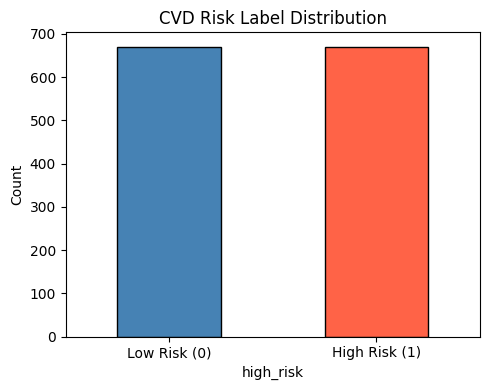

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
df = pd.read_csv("/Users/etsub/Desktop/4400 proj/cvd_data_cleaned.csv")
 
# Isolate outcome records (mortality + hospitalization)
outcome_questions = [
    'Coronary heart disease mortality among all people, underlying cause',
    'Diseases of the heart mortality among all people, underlying cause',
    'Hospitalization for heart failure as principal diagnosis, Medicare-beneficiaries aged 65 years and older'
]
 
# Use Age-adjusted Rate so values are comparable across demographics
outcome_df = df[
    (df['Question'].isin(outcome_questions)) &
    (df['DataValueType'] == 'Age-adjusted Rate')
].copy()
 
print(f"Outcome records (age-adjusted rate): {outcome_df.shape[0]}")
 
# Compute composite CVD burden score per group 
# Average the age-adjusted rates across all outcome questions per group
group_keys = ['LocationAbbr', 'YearStart', 'Stratification1']
 
burden_df = (
    outcome_df
    .groupby(group_keys)['DataValue']
    .mean()
    .reset_index()
    .rename(columns={'DataValue': 'cvd_burden_score'})
)
 
print(f"Unique groups with burden score: {burden_df.shape[0]}")
 
# Threshold at median → binary label 
median_burden = burden_df['cvd_burden_score'].median()
print(f"\nMedian CVD burden score (threshold): {median_burden:.2f}")
 
burden_df['high_risk'] = (burden_df['cvd_burden_score'] >= median_burden).astype(int)
 
# Check label distribution 
label_counts = burden_df['high_risk'].value_counts()
print(f"\nLabel distribution:")
print(f"  Low risk  (0): {label_counts[0]} ({100*label_counts[0]/len(burden_df):.1f}%)")
print(f"  High risk (1): {label_counts[1]} ({100*label_counts[1]/len(burden_df):.1f}%)")
 
# Isolate risk factor records (X)
risk_factor_questions = [
    'Taking medicine to control high blood pressure among adults with high blood pressure',
    'High cholesterol among adults who have been screened',
    'Taking medicine for high cholesterol among adults',
    'High blood pressure among adults'
]
 
risk_df = df[
    (df['Question'].isin(risk_factor_questions)) &
    (df['DataValueType'].isin(['Crude Prevalence', 'Age-adjusted Prevalence']))
].copy()
 
print(f"\nRisk factor records: {risk_df.shape[0]}")
 
# Pivot so each question becomes a column
risk_pivot = risk_df.pivot_table(
    index=group_keys,
    columns='Question',
    values='DataValue',
    aggfunc='mean'
).reset_index()
 
# Flatten column names
risk_pivot.columns = [
    col if col in group_keys else col.split(' among')[0].strip()
    for col in risk_pivot.columns
]
 
print(f"\nRisk factor feature matrix shape: {risk_pivot.shape}")
print(f"Columns: {risk_pivot.columns.tolist()}")
 
# Merge X and y 
merged_df = risk_pivot.merge(burden_df[group_keys + ['high_risk']], on=group_keys, how='inner')
 
print(f"\nFinal merged dataset shape: {merged_df.shape}")
print(f"Missing values per column:\n{merged_df.isnull().sum()}")
print(f"\nSample rows:")
print(merged_df.head())
 

merged_df.to_csv('/Users/etsub/Desktop/4400 proj/cvd_modeling.csv', index=False)
print("\nSaved to cvd_modeling_ready.csv")
 
#  Plot
plt.figure(figsize=(5, 4))
label_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['Low Risk (0)', 'High Risk (1)'], rotation=0)
plt.ylabel('Count')
plt.title('CVD Risk Label Distribution')
plt.tight_layout()
plt.show()
plt.savefig('/Users/etsub/Desktop/4400 proj/label_distribution.png', dpi=150)
print("Saved label distribution plot")

Training set size: 599
Testing set size:  150

Logistic Regression Performance 
  Accuracy : 0.7733
  Precision: 0.7753
  Recall   : 0.8313
  F1 Score : 0.8023
  ROC-AUC  : 0.8301

5-Fold Cross-Validation F1 Scores: [0.82840237 0.85227273 0.8        0.79289941 0.74358974]
Mean CV F1: 0.8034 (+/- 0.0366)

Feature Coefficients
  High blood pressure: 1.6613
  High cholesterol: 0.1353
  Taking medicine for high cholesterol: 0.0576
  Taking medicine to control high blood pressure: -0.1160


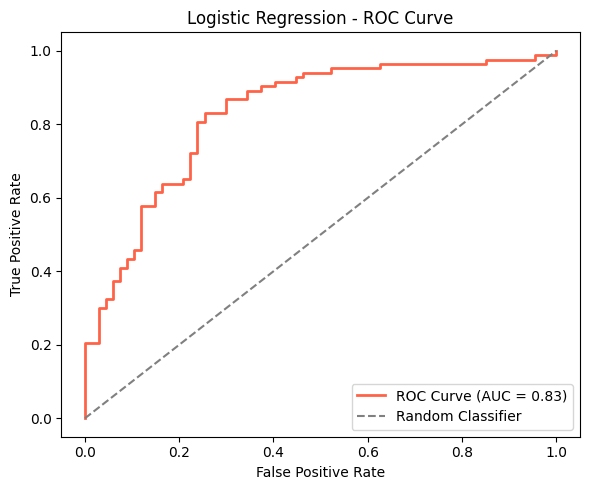


Saved ROC curve


<Figure size 640x480 with 0 Axes>

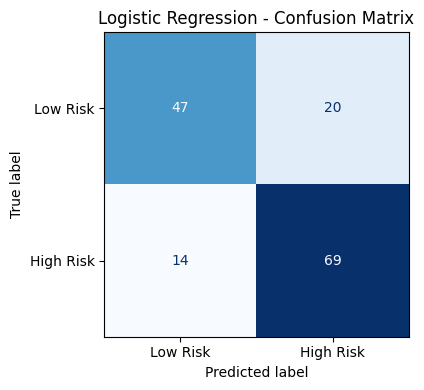

Saved confusion matrix


<Figure size 640x480 with 0 Axes>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Load modeling-ready dataset 
df = pd.read_csv('/Users/etsub/Desktop/4400 proj/cvd_modeling.csv')

feature_cols = [
    'High blood pressure',
    'High cholesterol',
    'Taking medicine for high cholesterol',
    'Taking medicine to control high blood pressure'
]

X = df[feature_cols]
y = df['high_risk']

# Impute missing values (mean imputation) 
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")

# Train logistic regression with gradient descent 
model = LogisticRegression(solver='saga', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions 
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation metrics 
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("\nLogistic Regression Performance ")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")

# Cross-validation 
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
print(f"\n5-Fold Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Feature importance (coefficients) 
print("\nFeature Coefficients")
for feat, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

# ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.savefig('/Users/etsub/Desktop/4400 proj/roc_curve_lr.png', dpi=150)
print("\nSaved ROC curve")

#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()
plt.savefig('/Users/etsub/Desktop/4400 proj/confusion_matrix_lr.png', dpi=150)
print("Saved confusion matrix")

Training set size: 599
Testing set size:  150

Converged after 7 iterations

Linear Perceptron Performance
  Accuracy : 0.7533
  Precision: 0.7347
  Recall   : 0.8675
  F1 Score : 0.7956
  ROC-AUC  : 0.8225

5-Fold Cross-Validation F1 Scores: [0.7826087  0.83229814 0.39455782 0.37681159 0.69863014]
Mean CV F1: 0.6170 (+/- 0.1937)

Feature Weights
  High blood pressure: 0.3691
  High cholesterol: -0.0032
  Taking medicine for high cholesterol: 0.0780
  Taking medicine to control high blood pressure: 0.0813


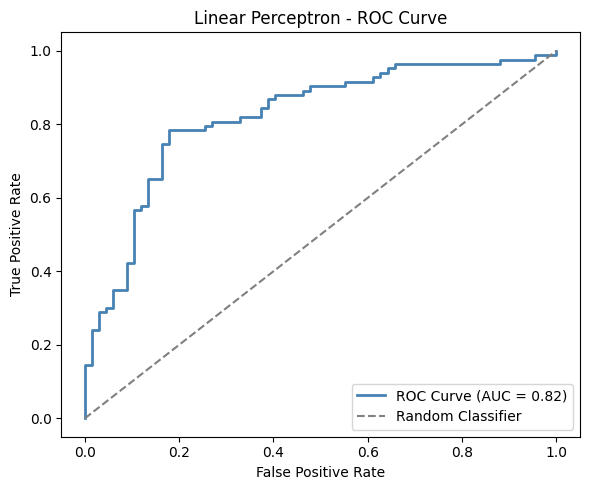


Saved ROC curve


<Figure size 640x480 with 0 Axes>

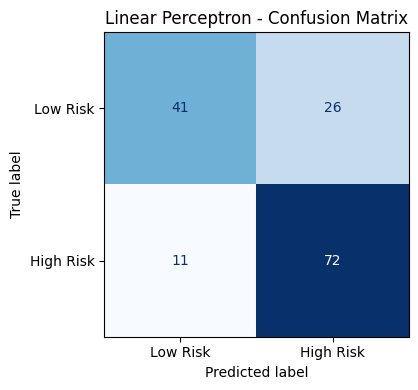

Saved confusion matrix


<Figure size 640x480 with 0 Axes>

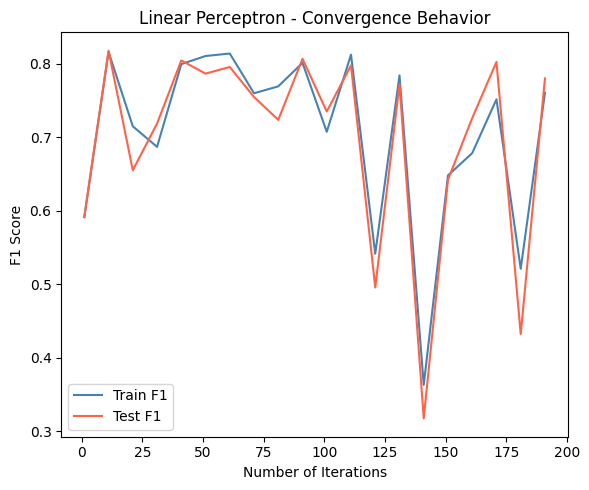

Saved convergence plot


<Figure size 640x480 with 0 Axes>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

df = pd.read_csv('/Users/etsub/Desktop/4400 proj/cvd_modeling.csv')

feature_cols = [
    'High blood pressure',
    'High cholesterol',
    'Taking medicine for high cholesterol',
    'Taking medicine to control high blood pressure'
]

X = df[feature_cols]
y = df['high_risk']

# Impute missing values (mean imputation)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")

# Train linear perceptron
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42, tol=1e-3)
model.fit(X_train, y_train)

print(f"\nConverged after {model.n_iter_} iterations")

# Predictions
y_pred = model.predict(X_test)
y_scores = model.decision_function(X_test)

# Evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_scores)

print("\nLinear Perceptron Performance")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")

# Cross-validation
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
print(f"\n5-Fold Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Feature weights
print("\nFeature Weights")
for feat, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Linear Perceptron - ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.savefig('/Users/etsub/Desktop/4400 proj/roc_curve_perceptron.png', dpi=150)
print("\nSaved ROC curve")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Linear Perceptron - Confusion Matrix')
plt.tight_layout()
plt.show()
plt.savefig('/Users/etsub/Desktop/4400 proj/confusion_matrix_perceptron.png', dpi=150)
print("Saved confusion matrix")

# Convergence behavior
train_scores = []
test_scores = []
iter_range = range(1, 201, 10)

for n in iter_range:
    m = Perceptron(max_iter=n, eta0=0.1, random_state=42, tol=None, warm_start=False)
    m.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, m.predict(X_train)))
    test_scores.append(f1_score(y_test, m.predict(X_test)))

plt.figure(figsize=(6, 5))
plt.plot(iter_range, train_scores, label='Train F1', color='steelblue')
plt.plot(iter_range, test_scores, label='Test F1', color='tomato')
plt.xlabel('Number of Iterations')
plt.ylabel('F1 Score')
plt.title('Linear Perceptron - Convergence Behavior')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('/Users/etsub/Desktop/4400 proj/convergence_perceptron.png', dpi=150)
print("Saved convergence plot")